# 00 Device Physics and Trace

Every figure below is constructed in its owning cell. The numerical figures
read measured fixtures and fit or simulate them live; the device-mechanism
schematic is authored directly in Matplotlib. Figures always appear inline.
File export is optional and disabled by default.


## Configuration


In [29]:
from pathlib import Path
import hashlib, json, os, warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import curve_fit
from scipy import stats

RUN_PROFILE = os.getenv("MRL_RUN_PROFILE", "reduced")  # reduced | publication | smoke
DEVICE = os.getenv("MRL_DEVICE", "auto")
SELECTED_DEVICE = "cpu"  # these measured-data fits are NumPy/SciPy workloads
WORKERS = os.getenv("MRL_WORKERS", "auto")
SAVE_FIGURES = os.getenv("MRL_SAVE_FIGURES", "0") == "1"
OUTPUT_DIR = Path(os.getenv("MRL_OUTPUT_DIR", "generated_figures"))
OVERWRITE = os.getenv("MRL_OVERWRITE", "0") == "1"
RUN_EXTERNAL_DATA = os.getenv("MRL_RUN_EXTERNAL_DATA", "0") == "1"
ALLOW_DATA_DOWNLOADS = os.getenv("MRL_ALLOW_DATA_DOWNLOADS", "0") == "1"

if RUN_PROFILE not in {"reduced", "publication", "smoke"}:
    raise ValueError(f"unknown RUN_PROFILE={RUN_PROFILE!r}")

HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == "experiments" else HERE
DEVICE_DATA = ROOT / "data" / "device_model"
PUB = ROOT / "data" / "publication"
MANIFEST = json.loads((PUB / "figure_manifest.json").read_text(encoding="utf-8"))
FIGURES = {row["filename"]: row for row in MANIFEST["figures"]}
FIGURE_REPORT = []
plt.ioff()

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def finish(fig, filename, provenance_class, *, data_paths=(), seeds=None, details=None):
    """Display once, optionally save, close, and record figure provenance."""
    saved = None
    if SAVE_FIGURES:
        out = OUTPUT_DIR.expanduser().resolve()
        if "manuscript" in str(out).lower() and not OVERWRITE:
            raise FileExistsError("writing into a manuscript directory requires OVERWRITE=True")
        out.mkdir(parents=True, exist_ok=True)
        path = out / filename
        if path.exists() and not OVERWRITE:
            raise FileExistsError(path)
        fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
        saved = str(path)

    paths = [Path(path) for path in data_paths]
    record = dict(
        FIGURES[filename],
        runtime_profile=RUN_PROFILE,
        runtime_device=SELECTED_DEVICE,
        seeds=seeds if seeds is not None else FIGURES[filename].get("seeds"),
        data_files=[str(path.relative_to(ROOT)) for path in paths],
        runtime_data_hashes={str(path.relative_to(ROOT)): sha256(path) for path in paths},
        provenance_class=provenance_class,
        saved_path=saved,
        details=details or {},
    )
    FIGURE_REPORT.append(record)
    display(fig)
    plt.close(fig)
    return record

ITO_FIXTURE = DEVICE_DATA / "ito_relaxation_measurements.npz"

def ito_measurements():
    """Yield (source filename, time, |current|, median voltage) per real trace."""
    fixture = np.load(ITO_FIXTURE)
    offsets = fixture["offsets"]
    for index, filename in enumerate(fixture["source_filename"].astype(str)):
        sl = slice(int(offsets[index]), int(offsets[index + 1]))
        yield filename, fixture["time"][sl].copy(), fixture["current"][sl].copy(), float(fixture["voltage"][index])

print({"profile": RUN_PROFILE, "requested_device": DEVICE, "selected_device": SELECTED_DEVICE, "workers": WORKERS,
       "saving": SAVE_FIGURES, "external": RUN_EXTERNAL_DATA,
       "downloads": ALLOW_DATA_DOWNLOADS})


{'profile': 'reduced', 'requested_device': 'auto', 'selected_device': 'cpu', 'workers': 'auto', 'saving': False, 'external': False, 'downloads': False}


## Measured Device Transient

Real gold-contact current transients (three repeats per bias) are averaged
and plotted against the global KWW law. The lines are not per-trace refits.


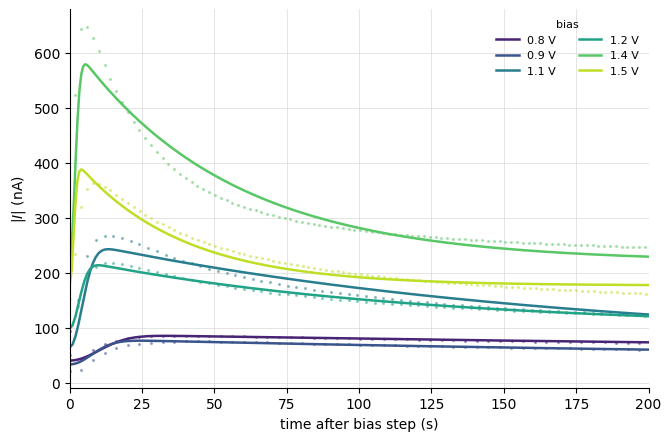

{'filename': 'fig_measured_transient.png',
 'tier': 'main',
 'notebook': '00_device_physics_and_trace.ipynb',
 'profile': 'publication',
 'device': 'cpu',
 'seeds': 3,
 'data_hash': '1b89943d4ac3659f9c8241351b54e0d6871b373d25f98fb163d582659fba0ccd',
 'reference_hash': '7f33e0cd14f3fdcb997c6b0bf1f99e603eacb6a702c7489faf6c1a3994194e75',
 'provenance_class': 'live-exact',
 'claim_status': 'measured-data-reproduction',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'data_files': ['data\\device_model\\kww_final.json',
  'data\\device_model\\gold_export\\trace_Vm0.80_tr1.csv',
  'data\\device_model\\gold_export\\trace_Vm0.80_tr2.csv',
  'data\\device_model\\gold_export\\trace_Vm0.80_tr3.csv',
  'data\\device_model\\gold_export\\trace_Vm0.90_tr1.csv',
  'data\\device_model\\gold_export\\trace_Vm0.90_tr2.csv',
  'data\\device_model\\gold_export\\trace_Vm0.90_tr3.csv',
  'data\\device_model\\gold_export\\trace_Vm1.10_tr1.csv',
  'data\\device_model\\gold_export\\trace_Vm1.10_tr2.csv'

In [30]:
"""Measured SiOx current transients with the global compressed-exponential fit."""
GOLD_EXPORT = DEVICE_DATA / "gold_export"
KWW_JSON = DEVICE_DATA / "kww_final.json"
VS = [0.8, 0.9, 1.1, 1.2, 1.4, 1.5]

fitted = json.loads(KWW_JSON.read_text(encoding="utf-8"))
laws, rows = fitted["laws"], fitted["rows"]
beta, tr0, cr = laws["beta"], laws["tr0"], laws["cr"]
td0, cd = laws["td0"], laws["cd"]

def model(t, V):
    """Global-law KWW model at bias |V|; A and C come from the per-V row."""
    row = rows[f"{V:.1f}"]
    tau_r = tr0 * np.exp(-cr * V)
    tau_d = td0 * np.exp(-cd * V)
    return row["A"] * (1 - np.exp(-(t / tau_r) ** beta)) * np.exp(-t / tau_d) + row["C"]

def traces_for(V):
    traces = []
    for path in sorted(GOLD_EXPORT.glob(f"trace_Vm{V:.2f}_tr*.csv")):
        values = np.genfromtxt(path, delimiter=",", names=True)
        t = np.asarray(values["time"], float)
        current = np.abs(np.asarray(values["current"], float))
        keep = np.isfinite(t) & np.isfinite(current) & (current > 0)
        traces.append((t[keep], current[keep]))
    if len(traces) != 3:
        raise ValueError(f"expected three measured repeats at {V:.1f} V, found {len(traces)}")
    return traces

fig, ax = plt.subplots(figsize=(6.6, 4.3))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(VS)))
for colour, V in zip(cmap, VS):
    traces = traces_for(V)
    tmax = min(t[-1] for t, _ in traces)
    tg = np.linspace(0, tmax, 300)
    mean_current = np.mean([np.interp(tg, t, current) for t, current in traces], axis=0)
    stride = max(1, len(tg) // 90)
    ax.plot(tg[::stride], mean_current[::stride] * 1e9, ".", color=colour, ms=2.6, alpha=0.4)
    ax.plot(tg, model(tg, V) * 1e9, "-", color=colour, lw=1.8, label=f"{V:.1f} V")

ax.set_xlabel("time after bias step (s)")
ax.set_ylabel(r"$|I|$ (nA)")
ax.set_xlim(0, 200)
ax.legend(fontsize=8, frameon=False, ncol=2, title="bias", title_fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, which="major", color="0.85", lw=0.5, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout(pad=0.3)
finish(fig, "fig_measured_transient.png", "live-exact",
       data_paths=[KWW_JSON, *sorted(GOLD_EXPORT.glob("trace_Vm*_tr*.csv"))], seeds=3)


## Eligibility Trace Shapes

A single real `TransientGate` is integrated at each retention setting. The
printed peak time and 1/e width make the retention control auditable.


tau_leak    peak time (s)    1/e width (s)
   20.0        37.20            inf
    5.0        12.02          13.72
    1.0         4.12           2.72


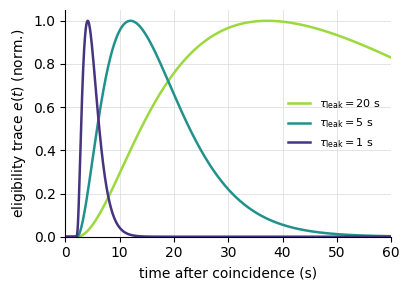

{'filename': 'fig_trace_shapes.png',
 'tier': 'supplementary',
 'notebook': '00_device_physics_and_trace.ipynb',
 'profile': 'publication',
 'device': 'cpu',
 'seeds': None,
 'data_hash': None,
 'reference_hash': 'e829c693abc345915f1a6794104a06d96d8af5b5e5ef4026d7f2c706588b6b68',
 'provenance_class': 'live-exact',
 'claim_status': 'model-reproduction',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'data_files': [],
 'runtime_data_hashes': {},
 'saved_path': None,
 'details': {20.0: {'peak_time_s': 37.2, 'one_over_e_width_s': inf},
  5.0: {'peak_time_s': 12.02, 'one_over_e_width_s': 13.720000000000002},
  1.0: {'peak_time_s': 4.12, 'one_over_e_width_s': 2.7199999999999998}}}

In [31]:
"""Device eligibility trace and its tunable retention."""
from mrl_trace import TransientGate

PALETTE = [plt.cm.viridis(x) for x in (0.85, 0.5, 0.15)]
dt = 0.02
t = np.arange(0, 60.0, dt)
tau_leaks = [20.0, 5.0, 1.0]

fig, ax = plt.subplots(figsize=(4.2, 3.0))
metrics = {}
print("tau_leak    peak time (s)    1/e width (s)")
for tau_leak, colour in zip(tau_leaks, PALETTE):
    gate = TransientGate(V=0.9, tau_leak=tau_leak, dt=dt)
    eligibility = gate.trace(t, coincidence_at=2.0, coincidence_dur=0.3, normalise=True)
    ax.plot(t, eligibility, color=colour, lw=1.8, label=fr"$\tau_{{\rm leak}}={tau_leak:g}$ s")
    peak_index = int(np.argmax(eligibility))
    below = np.where(eligibility[peak_index:] <= np.exp(-1))[0]
    width = (t[peak_index + below[0]] - t[peak_index]) if len(below) else np.inf
    metrics[tau_leak] = {"peak_time_s": float(t[peak_index]), "one_over_e_width_s": float(width)}
    print(f"  {tau_leak:5.1f}      {t[peak_index]:7.2f}        {width:7.2f}")

ax.set_xlabel("time after coincidence (s)")
ax.set_ylabel(r"eligibility trace $e(t)$ (norm.)")
ax.set_xlim(0, 60); ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, which="major", color="0.85", lw=0.5, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
finish(fig, "fig_trace_shapes.png", "live-exact", details=metrics)


## Dispersive Relaxation Kinetics

The complete device-mechanism schematic is generated directly below. It is
shown once; no raster copy is loaded.


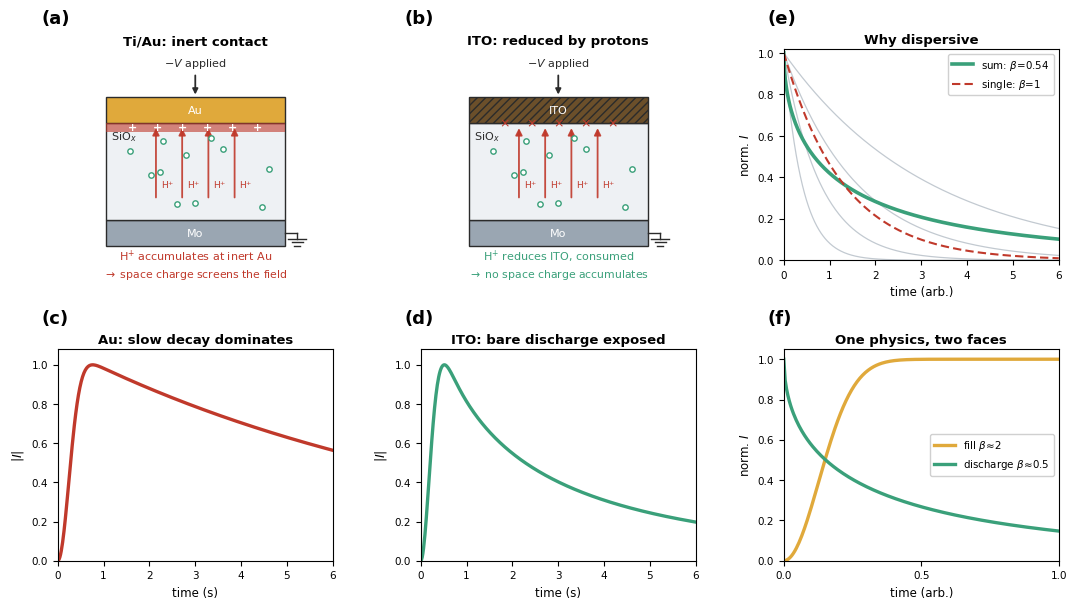

{'filename': 'fig_dispersive.png',
 'tier': 'supplementary',
 'notebook': '00_device_physics_and_trace.ipynb',
 'profile': 'publication',
 'device': 'cpu',
 'seeds': None,
 'data_hash': None,
 'reference_hash': '87d97019cac4ed90d48cb7b55a8a7023f14eef3e972def774bcae238abefded7',
 'provenance_class': 'immutable-authored',
 'claim_status': 'authored-schematic-reproduction',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'data_files': [],
 'runtime_data_hashes': {},
 'saved_path': None,
 'details': {}}

In [32]:
import os
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

INK   = "#2b2b2b"
MO    = "#9aa6b2"
OXIDE = "#eef1f4"
GOLD  = "#e0a93b"
ITO   = "#3aa07a"
ITOr  = "#6b4f2a"
TRAP  = "#3aa07a"
PROT  = "#c0392b"
GREEN = "#3aa07a"
NEU   = "#9aa6b2"

TRAP_PTS = None   # shared trap distribution, set in main()

def _stack(ax, reduced, top_color, top_label):
    """One MIM stack centred in the axes: Mo (grounded) / SiOx / top electrode (-V).

    Bias convention matches the device measurement: a negative bias is applied to
    the top electrode and the Mo bottom electrode is grounded, so the field drives
    the positive mobile species (a proton, with oxygen vacancies as the coupled
    species) UP toward the negatively-biased top electrode."""
    ax.set_xlim(0, 4); ax.set_ylim(0, 3.7); ax.axis("off")
    x0, w = 0.7, 2.6
    y_mo, h_mo = 0.25, 0.45
    y_ox, h_ox = 0.70, 1.7
    y_top, h_top = 2.40, 0.45
    # Mo bottom electrode (grounded)
    ax.add_patch(Rectangle((x0, y_mo), w, h_mo, fc=MO, ec=INK, lw=1.0, zorder=2))
    ax.text(x0+w/2, y_mo+h_mo/2, "Mo", ha="center", va="center", fontsize=8, color="white")
    # ground symbol on Mo
    gx = x0 + w + 0.18
    ax.plot([x0+w, gx], [y_mo+h_mo/2, y_mo+h_mo/2], color=INK, lw=1.0)
    for i, hw in enumerate([0.13, 0.08, 0.04]):
        yy = y_mo+h_mo/2 - 0.10 - 0.06*i
        ax.plot([gx-hw, gx+hw], [yy, yy], color=INK, lw=1.0)
    ax.plot([gx, gx], [y_mo+h_mo/2, y_mo+h_mo/2-0.10], color=INK, lw=1.0)
    # SiOx
    ax.add_patch(Rectangle((x0, y_ox), w, h_ox, fc=OXIDE, ec=INK, lw=1.0, zorder=2))
    ax.text(x0+0.08, y_ox+h_ox-0.12, r"SiO$_x$", ha="left", va="top", fontsize=8, color=INK)
    # top electrode + applied -V
    if reduced:
        ax.add_patch(Rectangle((x0, y_top), w, h_top, fc=ITOr, ec=INK, lw=1.0, zorder=2, hatch="////"))
    else:
        ax.add_patch(Rectangle((x0, y_top), w, h_top, fc=top_color, ec=INK, lw=1.0, zorder=2))
    ax.text(x0+w/2, y_top+h_top/2, top_label, ha="center", va="center", fontsize=8, color="white")
    ax.annotate(r"$-V$ applied", xy=(x0+w/2, y_top+h_top), xytext=(x0+w/2, y_top+h_top+0.55),
                ha="center", fontsize=8.0, color=INK,
                arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.3))
    # distributed traps (same pattern in both)
    xs = x0 + 0.18 + (w-0.36)*TRAP_PTS[:, 0]
    ys = y_ox + 0.20 + (h_ox-0.40)*TRAP_PTS[:, 1]
    ax.scatter(xs, ys, s=15, facecolor="white", edgecolor=TRAP, lw=1.0, zorder=4)
    # mobile positive species drifts UP toward the negative top electrode
    for fx in np.linspace(0.28, 0.72, 4):
        x = x0 + fx*w
        ax.annotate("", xy=(x, y_top-0.04), xytext=(x, y_ox+0.35),
                    arrowprops=dict(arrowstyle="-|>", color=PROT, lw=1.3, alpha=0.9))
        ax.text(x+0.07, y_ox+0.62, r"H$^{+}$", color=PROT, fontsize=6.6, va="center", zorder=5)
    return dict(x0=x0, w=w, y_top=y_top, y_ox=y_ox, h_ox=h_ox)

def panel_a(ax):
    ax.text(-0.06, 1.12, "(a)", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.text(0.5, 1.02, "Ti/Au: inert contact", transform=ax.transAxes,
            ha="center", fontsize=9.5, fontweight="bold")
    g = _stack(ax, reduced=False, top_color=GOLD, top_label="Au")
    # accumulation layer (+) just under the inert gold
    ax.add_patch(Rectangle((g["x0"], g["y_top"]-0.15), g["w"], 0.15, fc=PROT, ec="none", alpha=0.6, zorder=3))
    for fx in np.linspace(0.15, 0.85, 6):
        ax.text(g["x0"]+fx*g["w"], g["y_top"]-0.075, "+", color="white",
                ha="center", va="center", fontsize=8, fontweight="bold", zorder=5)
    ax.text(2.0, 0.00, r"H$^{+}$ accumulates at inert Au", ha="center", fontsize=8.0, color=PROT)
    ax.text(2.0, -0.30, "$\\rightarrow$ space charge screens the field", ha="center", fontsize=7.8, color=PROT)

def panel_b(ax):
    ax.text(-0.06, 1.12, "(b)", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.text(0.5, 1.02, "ITO: reduced by protons", transform=ax.transAxes,
            ha="center", fontsize=9.5, fontweight="bold")
    g = _stack(ax, reduced=True, top_color=ITO, top_label="ITO")
    for fx in np.linspace(0.2, 0.8, 5):
        ax.text(g["x0"]+fx*g["w"], g["y_top"]-0.01, r"$\times$", color=PROT,
                ha="center", va="center", fontsize=9, fontweight="bold", zorder=5)
    ax.text(2.0, 0.00, r"H$^{+}$ reduces ITO, consumed", ha="center", fontsize=8.0, color=GREEN)
    ax.text(2.0, -0.30, "$\\rightarrow$ no space charge accumulates", ha="center", fontsize=7.8, color=GREEN)

def _transient_axes(ax):
    ax.set_xlim(0, 6); ax.set_ylim(0, 1.08)
    ax.set_xlabel("time (s)", fontsize=8.5); ax.set_ylabel(r"$|I|$", fontsize=9)
    ax.tick_params(labelsize=7.5)

def panel_c(ax):
    """Gold transient: rise then slow tau_d decay -> masks the discharge."""
    ax.text(-0.06, 1.12, "(c)", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.set_title("Au: slow decay dominates", fontsize=9.5, fontweight="bold", pad=4)
    t = np.linspace(0, 6, 400)
    rise = 1 - np.exp(-(t/0.35)**2)
    I = rise*np.exp(-t/9.0); I = I/I.max()
    ax.plot(t, I, color=PROT, lw=2.4)
    _transient_axes(ax)
    # (tau_d arrow and "trap discharge hidden underneath" text removed -- the
    #  caption states the slow proton decay masks the faster trap discharge)

def panel_d(ax):
    """ITO transient: bare dispersive discharge exposed -> tau_leak."""
    ax.text(-0.06, 1.12, "(d)", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.set_title("ITO: bare discharge exposed", fontsize=9.5, fontweight="bold", pad=4)
    t = np.linspace(0, 6, 400)
    rise = 1 - np.exp(-(t/0.30)**2)
    I = rise*np.exp(-(t/1.3)**0.54); I = I/I.max()
    ax.plot(t, I, color=TRAP, lw=2.4)
    _transient_axes(ax)
    # (tau_leak arrow/annotation removed -- the caption states ITO exposes the
    #  bare discharge tau_leak)

def panel_e(ax):
    """Why dispersive: distribution of rates -> stretched exponential."""
    ax.text(-0.06, 1.12, "(e)", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.set_title("Why dispersive", fontsize=9.5, fontweight="bold", pad=4)
    t = np.linspace(0, 6, 400)
    for tt in [0.4, 0.8, 1.6, 3.2]:
        ax.plot(t, np.exp(-t/tt), color=NEU, lw=0.9, alpha=0.6)
    ax.plot(t, np.exp(-(t/1.3)**0.54), color=TRAP, lw=2.6, label=r"sum: $\beta\!=\!0.54$")
    ax.plot(t, np.exp(-t/1.3), color=PROT, lw=1.5, ls=(0, (4, 2)), label=r"single: $\beta\!=\!1$")
    ax.set_xlim(0, 6); ax.set_ylim(0, 1.02)
    ax.set_xlabel("time (arb.)", fontsize=8.5); ax.set_ylabel("norm. $I$", fontsize=8.5)
    ax.tick_params(labelsize=7.5)
    ax.legend(fontsize=7.4, loc="upper right", framealpha=0.92)
    # ("grey: individual release rates" floating text removed -- caption explains
    #  the spread of release rates summing to a stretched exponential)

def panel_f(ax):
    """One physics, two faces: compressed fill mirrors stretched discharge."""
    ax.text(-0.06, 1.12, "(f)", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.set_title("One physics, two faces", fontsize=9.5, fontweight="bold", pad=4)
    t = np.linspace(0, 1, 200)
    ax.plot(t, 1-np.exp(-(t/0.18)**2), color=GOLD, lw=2.4, label=r"fill $\beta\!\approx\!2$")
    ax.plot(t, np.exp(-(t/0.30)**0.54), color=TRAP, lw=2.4, label=r"discharge $\beta\!\approx\!0.5$")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_xlabel("time (arb.)", fontsize=8.5); ax.set_ylabel("norm. $I$", fontsize=8.5)
    ax.set_xticks([0, 0.5, 1.0]); ax.tick_params(labelsize=7.5)
    # floating "fill/discharge" labels and the italic subtitle removed; the two
    # curves are distinguished by a compact legend and explained in the caption
    ax.legend(fontsize=7.4, loc="center right", framealpha=0.92)

TRAP_PTS = np.random.RandomState(7).rand(11, 2)
fig, axes = plt.subplots(2, 3, figsize=(11.0, 6.4))
panel_a(axes[0, 0]); panel_b(axes[0, 1]); panel_e(axes[0, 2])
panel_c(axes[1, 0]); panel_d(axes[1, 1]); panel_f(axes[1, 2])
fig.subplots_adjust(left=0.06, right=0.97, top=0.92, bottom=0.12, wspace=0.32, hspace=0.42)

finish(fig, "fig_dispersive.png", "immutable-authored")


## Field-Free Trace Decay

Runs 471 and 498 are fitted live at their near-zero read field. These are the
two preliminary measured devices used by the authored generator.


Run498: V=1mV tau=9.1s beta=0.86 R2=0.998
Run471: V=1mV tau=4.3s beta=0.82 R2=0.877


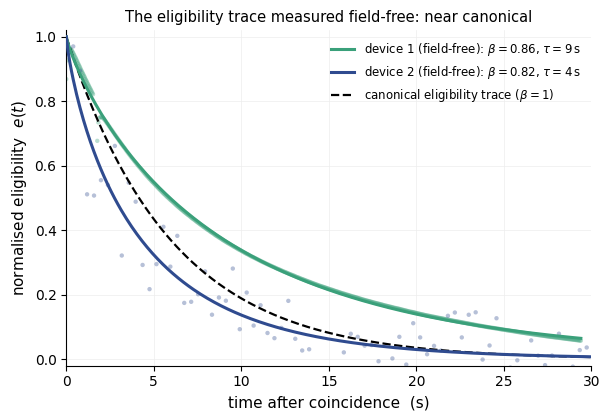

{'filename': 'fig_fieldfree_trace.png',
 'tier': 'supplementary',
 'notebook': '00_device_physics_and_trace.ipynb',
 'profile': 'publication',
 'device': 'cpu',
 'seeds': 2,
 'data_hash': '823cf1d92d272c1d6425e74c4b7ada0770be9c47b8dfa2a552c2e165f97fd7f4',
 'reference_hash': '7fc958e79e62a04723f99ad1b322d083a850b420f0cf2c205a6ce4bbd733d314',
 'provenance_class': 'live-exact',
 'claim_status': 'measured-data-reproduction',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'data_files': ['data\\device_model\\ito_relaxation_measurements.npz'],
 'runtime_data_hashes': {'data\\device_model\\ito_relaxation_measurements.npz': '823cf1d92d272c1d6425e74c4b7ada0770be9c47b8dfa2a552c2e165f97fd7f4'},
 'saved_path': None,
 'details': {'498': {'read_voltage_V': 0.0010000000474974513,
   'tau_s': 9.095738519429712,
   'beta': 0.8573753202358726,
   'R2': 0.9983074792905999},
  '471': {'read_voltage_V': 0.0010000000474974513,
   'tau_s': 4.316926548936238,
   'beta': 0.8168858596868124,
   'R2': 

In [33]:
"""Eligibility trace measured in its near-zero-field operating regime."""
warnings.filterwarnings("ignore")
FIELD_FREE_RUNS = {
    "498": ("#3aa07a", "device 1"),
    "471": ("#2f4b8f", "device 2"),
}

def field_free_trace(run):
    matches = [(name, t, current, voltage) for name, t, current, voltage in ito_measurements()
               if f"Run{run} " in name]
    if len(matches) != 1:
        raise ValueError(f"expected one measured Run{run}, found {len(matches)}")
    _, t, current, voltage = matches[0]
    return t - t[0], current, voltage

def stretched_field_free(t, amplitude, tau, beta, floor):
    return amplitude * np.exp(-(t / abs(tau)) ** abs(beta)) + floor

def r2(y, fitted_y):
    return 1 - np.sum((y - fitted_y) ** 2) / np.sum((y - np.mean(y)) ** 2)

fig, ax = plt.subplots(figsize=(6.2, 4.3))
fit_summary = {}
for run, (colour, label) in FIELD_FREE_RUNS.items():
    t, current, voltage = field_free_trace(run)
    normalised_current = current / current.max()
    params, _ = curve_fit(
        stretched_field_free, t, normalised_current,
        p0=[normalised_current.max() - normalised_current.min(), t[-1] / 3, 0.7,
            normalised_current[-5:].mean()],
        bounds=([0, 1e-2, 0.2, 0], [5, 1e4, 2.0, 2]),
        maxfev=200000, ftol=1e-12, xtol=1e-12,
    )
    amplitude, tau, beta, floor = map(abs, params)
    score = r2(normalised_current, stretched_field_free(t, *params))
    eligibility = (normalised_current - floor) / amplitude
    ax.scatter(t, eligibility, s=10, c=colour, alpha=0.35, edgecolor="none", zorder=2)
    ts = np.linspace(0, t[-1], 400)
    ax.plot(ts, np.exp(-(ts / tau) ** beta), c=colour, lw=2.2, zorder=4,
            label=rf"{label} (field-free): $\beta={beta:.2f}$, $\tau={tau:.0f}\,\mathrm{{s}}$")
    fit_summary[run] = {"read_voltage_V": voltage, "tau_s": tau, "beta": beta, "R2": score}
    print(f"Run{run}: V={voltage*1e3:.0f}mV tau={tau:.1f}s beta={beta:.2f} R2={score:.3f}")

ts = np.linspace(0, 30, 400)
ax.plot(ts, np.exp(-ts / 6.0), color="k", ls="--", lw=1.6, zorder=3,
        label=r"canonical eligibility trace ($\beta=1$)")
ax.set_xlim(0, 30); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("time after coincidence  (s)", fontsize=11)
ax.set_ylabel(r"normalised eligibility  $e(t)$", fontsize=11)
ax.set_title("The eligibility trace measured field-free: near canonical", fontsize=10.5)
ax.legend(fontsize=8.5, frameon=False, loc="upper right")
ax.grid(True, color="0.93", lw=0.5); ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
finish(fig, "fig_fieldfree_trace.png", "live-exact", data_paths=[ITO_FIXTURE],
       seeds=2, details=fit_summary)


## Intrinsic Trace Timescales

The measured device ranges, model-set retention values, and literature
biological window are laid on one logarithmic axis.


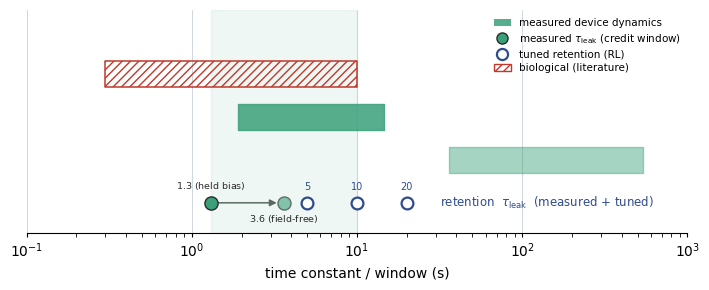

{'filename': 'fig_timescales.png',
 'tier': 'context',
 'notebook': '00_device_physics_and_trace.ipynb',
 'profile': 'publication',
 'device': 'cpu',
 'seeds': None,
 'data_hash': None,
 'reference_hash': '28ce816043cd8cfedf03cee55c535f9703947b390387f4a897fe0f0fb4268710',
 'provenance_class': 'live-exact',
 'claim_status': 'measured-parameter-summary',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'data_files': ['data\\device_model\\kww_final.json',
  'data\\device_model\\ito_relaxation_measurements.npz'],
 'runtime_data_hashes': {'data\\device_model\\kww_final.json': 'abb510ecb3b4b87dbef1b5902d648d11034aa150a0921372e3442a18ea412abe',
  'data\\device_model\\ito_relaxation_measurements.npz': '823cf1d92d272c1d6425e74c4b7ada0770be9c47b8dfa2a552c2e165f97fd7f4'},
 'saved_path': None,
 'details': {}}

In [ ]:
"""Device/biology timescale ladder from the authored generator."""
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

TEAL = "#3aa07a"; INDIGO = "#2f4b8f"; BRICK = "#c0392b"; INK = "#2b2b2b"; GRID = "#c8d0d8"
BIO = (0.3, 10.0)
TAU_R = (1.9, 14.5)
TAU_D = (36.0, 537.0)
TAU_LEAK_MEAS = 1.3
TAU_LEAK_FF = 3.6
TAU_LEAK = [5, 10, 20]
OVERLAP = (max(BIO[0], TAU_LEAK_MEAS), min(BIO[1], TAU_R[1]))
Y_BIO, Y_R, Y_D, Y_LEAK, BAR_H = 3, 2, 1, 0, 0.30

fig, ax = plt.subplots(figsize=(7.2, 3.0))
ax.axvspan(OVERLAP[0], OVERLAP[1], color=TEAL, alpha=0.08, zorder=0)
# ax.text(np.sqrt(OVERLAP[0] * OVERLAP[1]), 4.05,
#         "device dynamics meet\nthe biological window", ha="center", va="center",
#         fontsize=7.0, style="italic", color="#5a6b62", linespacing=1.05, zorder=5)
ax.fill_between(BIO, Y_BIO-BAR_H, Y_BIO+BAR_H, facecolor="none", edgecolor=BRICK,
                hatch="////", linewidth=1.1, zorder=3)
# ax.text(BIO[1]*1.35, Y_BIO, "biological eligibility window (~0.3-10 s)",
        # va="center", ha="left", fontsize=8.5, color=BRICK)
ax.fill_between(TAU_R, Y_R-BAR_H, Y_R+BAR_H, color=TEAL, alpha=0.85, zorder=3)
# ax.text(TAU_R[1]*1.35, Y_R, r"device rise  $\tau_r$  (measured, 1.9-14.5 s)",
#         va="center", ha="left", fontsize=8.5, color=INK)
ax.fill_between(TAU_D, Y_D-BAR_H, Y_D+BAR_H, color=TEAL, alpha=0.45, zorder=3)
# ax.text(TAU_D[0]*0.62, Y_D, r"device decay  $\tau_d$  (measured, 36-537 s)",
#         va="center", ha="right", fontsize=8.5, color=INK)
ax.annotate("", xy=(TAU_LEAK_FF, Y_LEAK), xytext=(TAU_LEAK_MEAS, Y_LEAK),
            arrowprops=dict(arrowstyle="-|>", color="#5a6b62", lw=1.1, shrinkA=5, shrinkB=5), zorder=4)
ax.plot([TAU_LEAK_MEAS], [Y_LEAK], marker="o", ms=9.5, mfc=TEAL, mec=INK, mew=1.0, zorder=5)
# ax.annotate(r"$1.3$ (held bias)", (TAU_LEAK_MEAS, Y_LEAK), textcoords="offset points",
#             xytext=(0, 10), ha="center", fontsize=6.8, color=INK)
ax.plot([TAU_LEAK_FF], [Y_LEAK], marker="o", ms=9.5, mfc=TEAL, alpha=0.6,
        mec=INK, mew=1.0, zorder=5)
# ax.annotate(r"$3.6$ (field-free)", (TAU_LEAK_FF, Y_LEAK), textcoords="offset points",
#             xytext=(0, -14), ha="center", fontsize=6.8, color=INK)
for retention in TAU_LEAK:
    ax.plot([retention], [Y_LEAK], marker="o", ms=8.5, mfc="white", mec=INDIGO, mew=1.6, zorder=4)
    ax.annotate(f"{retention}", (retention, Y_LEAK), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=7, color=INDIGO)
# ax.text(TAU_LEAK[-1]*1.6, Y_LEAK, r"retention  $\tau_{\mathrm{leak}}$  (measured $+$ tuned)",
#         va="center", ha="left", fontsize=8.5, color=INDIGO)
ax.set_xscale("log"); ax.set_xlim(0.1, 1000); ax.set_ylim(-0.7, 4.5)
ax.set_xlabel("time constant / window (s)"); ax.set_yticks([])
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", which="both", length=3)
ax.grid(True, axis="x", which="major", color=GRID, lw=0.6, zorder=0); ax.set_axisbelow(True)
legend_handles = [
    Patch(facecolor=TEAL, alpha=0.85, label="measured device dynamics"),
    Line2D([0], [0], marker="o", color="none", mfc=TEAL, mec=INK, mew=1.0, ms=8,
           label=r"measured $\tau_{\mathrm{leak}}$ (credit window)"),
    Line2D([0], [0], marker="o", color="none", mfc="white", mec=INDIGO, mew=1.6, ms=8,
           label="tuned retention (RL)"),
    Patch(facecolor="none", edgecolor=BRICK, hatch="////", label="biological (literature)"),
]
ax.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(1.0, 0.99),
          frameon=False, fontsize=7.5, handlelength=1.6, borderaxespad=0.2, labelspacing=0.35)
fig.tight_layout()
finish(fig, "fig_timescales.png", "live-exact", data_paths=[DEVICE_DATA / "kww_final.json", ITO_FIXTURE])


## ITO Electrode Trap Filling

Every held-bias relaxation is refitted live. The steady-state floor separates
filling from emission and yields the field-free retention estimate.


n=53 held-bias tau median 1.34s rho median 0.11 field-free tau median 1.61s


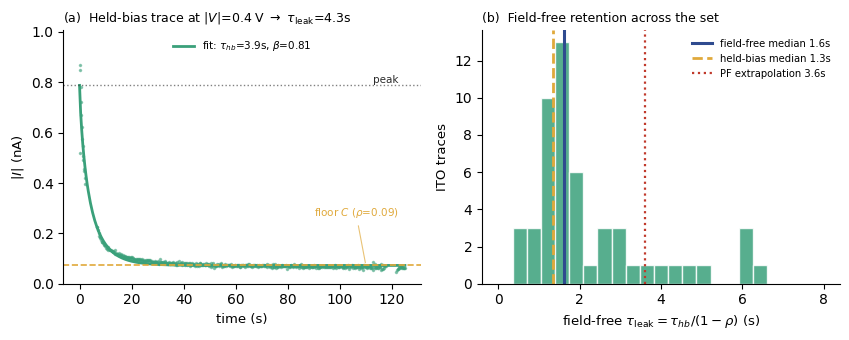

{'filename': 'fig_ito_fillsep.png',
 'tier': 'context',
 'notebook': '00_device_physics_and_trace.ipynb',
 'profile': 'publication',
 'device': 'cpu',
 'seeds': 53,
 'data_hash': '823cf1d92d272c1d6425e74c4b7ada0770be9c47b8dfa2a552c2e165f97fd7f4',
 'reference_hash': '5a158a6952c1f6255a36ec347b616e3bd8aafcf9c27cbe86301c15487a3a20ce',
 'provenance_class': 'live-exact',
 'claim_status': 'measured-data-reproduction',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'data_files': ['data\\device_model\\ito_relaxation_measurements.npz'],
 'runtime_data_hashes': {'data\\device_model\\ito_relaxation_measurements.npz': '823cf1d92d272c1d6425e74c4b7ada0770be9c47b8dfa2a552c2e165f97fd7f4'},
 'saved_path': None,
 'details': {'n_fits': 53,
  'held_bias_median_s': 1.3412143244202508,
  'field_free_median_s': 1.611553333519101}}

In [35]:
"""Fill/emission separation of held-bias ITO discharge."""
warnings.filterwarnings("ignore")
INK = "#2b2b2b"; DEVICE_C = "#3aa07a"; FF = "#2f4b8f"; HB = "#e0a93b"; PF = "#c0392b"

def stretched_floor(t, amplitude, tau, beta, floor):
    return amplitude * np.exp(-(t / abs(tau)) ** abs(beta)) + abs(floor)

fits = []
example = None
for filename, t, current, voltage in ito_measurements():
    if "06-26-2026" in filename or len(current) < 60 or not np.isfinite(voltage):
        continue
    n = len(current); peak_index = int(np.argmax(current))
    if not (peak_index < 0.05*n and current[-1]/current.max() < 0.5):
        continue
    t = t - t[0]
    try:
        params, _ = curve_fit(stretched_floor, t, current,
                              p0=[current.max()-current.min(), t[-1]/3, 0.6, current[-1]],
                              maxfev=20000)
        amplitude, tau, beta, floor = map(abs, params)
        score = r2(current, stretched_floor(t, *params))
        if score < 0.7:
            continue
        peak = amplitude + floor; rho = floor / peak
        if rho >= 0.97:
            continue
        tau_ff = tau / (1-rho)
        fits.append((abs(voltage), tau, rho, tau_ff))
        if example is None and 0.4 <= abs(voltage) <= 0.6:
            example = (t, current, params, tau, rho, tau_ff, abs(voltage))
    except Exception:
        pass

fits = np.asarray(fits)
if len(fits) == 0 or example is None:
    raise RuntimeError("measured ITO fixture produced no valid fill/emission fits")
voltage, tau, rho, tau_ff = fits.T
median_hb, median_ff = np.median(tau), np.median(tau_ff)
print(f"n={len(fits)} held-bias tau median {median_hb:.2f}s rho median {np.median(rho):.2f} "
      f"field-free tau median {median_ff:.2f}s")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(8.6, 3.5))
t, current, params, tau_example, rho_example, tau_ff_example, voltage_example = example
tg = np.linspace(t[0], t[-1], 300)
amplitude, _, beta_example, floor = map(abs, params)
axA.plot(t, current*1e9, ".", color=DEVICE_C, ms=3, alpha=0.5)
axA.plot(tg, stretched_floor(tg, *params)*1e9, "-", color=DEVICE_C, lw=2,
         label=rf"fit: $\tau_{{hb}}$={tau_example:.1f}s, $\beta$={beta_example:.2f}")
axA.axhline((amplitude+floor)*1e9, color=INK, ls=":", lw=1, alpha=0.6)
axA.axhline(floor*1e9, color=HB, ls="--", lw=1.2)
axA.set_ylim(0, (amplitude+floor)*1e9*1.28)
axA.text(t[-1]*0.98, (amplitude+floor)*1e9, "peak", fontsize=7.5, va="bottom", ha="right", color=INK)
axA.annotate(f"floor $C$ ($\\rho$={rho_example:.2f})", xy=(t[-1]*0.88, floor*1e9),
             xytext=(t[-1]*0.98, (amplitude+floor)*1e9*0.32), fontsize=7.5,
             va="bottom", ha="right", color=HB,
             arrowprops=dict(arrowstyle="-", color=HB, lw=0.8, alpha=0.7))
axA.set_xlabel("time (s)", fontsize=9.5); axA.set_ylabel(r"$|I|$ (nA)", fontsize=9.5)
axA.set_title(rf"(a)  Held-bias trace at $|V|$={voltage_example:.1f} V $\to\ \tau_{{\rm leak}}$={tau_ff_example:.1f}s",
              fontsize=9, loc="left")
axA.legend(fontsize=7.5, frameon=False, loc="upper center")
for spine in ("top", "right"): axA.spines[spine].set_visible(False)

axB.hist(tau_ff, bins=np.linspace(0, 8, 24), color=DEVICE_C, alpha=0.85, edgecolor="white")
axB.axvline(median_ff, color=FF, lw=2.2, label=rf"field-free median {median_ff:.1f}s")
axB.axvline(median_hb, color=HB, lw=2.0, ls="--", label=rf"held-bias median {median_hb:.1f}s")
axB.axvline(3.6, color=PF, lw=1.6, ls=":", label="PF extrapolation 3.6s")
axB.set_xlabel(r"field-free $\tau_{\mathrm{leak}}=\tau_{hb}/(1-\rho)$ (s)", fontsize=9.5)
axB.set_ylabel("ITO traces", fontsize=9.5)
axB.set_title("(b)  Field-free retention across the set", fontsize=9, loc="left")
axB.legend(fontsize=7.2, frameon=False)
for spine in ("top", "right"): axB.spines[spine].set_visible(False)
fig.tight_layout()
finish(fig, "fig_ito_fillsep.png", "live-exact", data_paths=[ITO_FIXTURE], seeds=len(fits),
       details={"n_fits": len(fits), "held_bias_median_s": median_hb, "field_free_median_s": median_ff})


## ITO Field-Dependent Time Constants

The same accepted measured decays are refitted live for the Poole–Frenkel
field law and the field dependence of the dispersion exponent.


n=53; field-free tau=3.56s [2.35,5.72]; beta slope=-0.326/decade p=1.8e-08; beta(1mV)=1.46


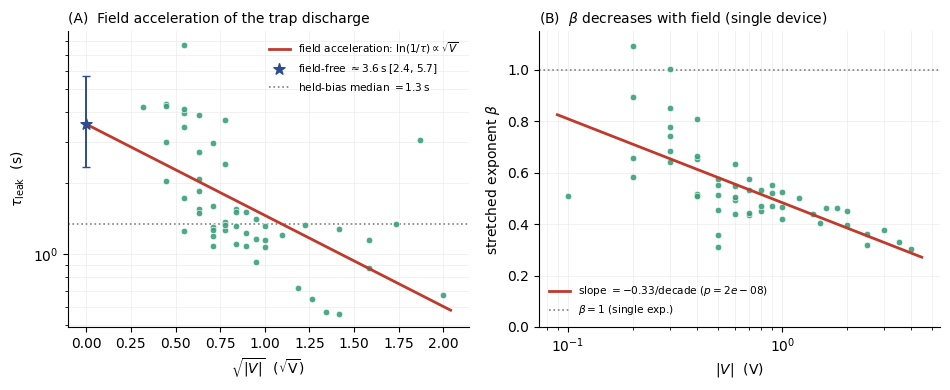

{'filename': 'fig_ito_taufield.png',
 'tier': 'context',
 'notebook': '00_device_physics_and_trace.ipynb',
 'profile': 'publication',
 'device': 'cpu',
 'seeds': 53,
 'data_hash': '823cf1d92d272c1d6425e74c4b7ada0770be9c47b8dfa2a552c2e165f97fd7f4',
 'reference_hash': '3558b4ca2454ada9971b7b3aad7a41a57b8d9ab04665c657f30baa562441ba38',
 'provenance_class': 'live-exact',
 'claim_status': 'measured-data-reproduction',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'data_files': ['data\\device_model\\ito_relaxation_measurements.npz'],
 'runtime_data_hashes': {'data\\device_model\\ito_relaxation_measurements.npz': '823cf1d92d272c1d6425e74c4b7ada0770be9c47b8dfa2a552c2e165f97fd7f4'},
 'saved_path': None,
 'details': {'n_fits': 53,
  'bootstrap_samples': 10000,
  'tau_zero_s': 3.5613290217192244,
  'tau_zero_ci95_s': [2.353601572327028, 5.722423461513227],
  'beta_slope_per_decade': -0.3256659587829827,
  'beta_p': 1.8453960830970742e-08}}

In [36]:
"""Field dependence of ITO tau_leak and beta."""
SEED = 7
N_BOOT = 300 if RUN_PROFILE == "smoke" else 10000

def collect_field_fits():
    accepted = []
    for filename, t, current, voltage in ito_measurements():
        if "06-26-2026" in filename or len(current) < 60 or not np.isfinite(voltage) or abs(voltage) < 1e-3:
            continue
        n = len(current); peak_index = int(np.argmax(current))
        if peak_index < 0.15*n and current[-5:].mean()/current.max() < 0.7:
            t = t - t[0]; normalised = current/current.max()
            try:
                params, _ = curve_fit(stretched_field_free, t, normalised,
                                      p0=[normalised.max()-normalised.min(), t[-1]/3, 0.7,
                                          normalised[-5:].mean()],
                                      bounds=([0, 1e-2, 0.2, 0], [5, 1e4, 2.0, 2]),
                                      maxfev=200000, ftol=1e-12, xtol=1e-12)
                score = r2(normalised, stretched_field_free(t, *params))
                if score > 0.70 and 0.25 < abs(params[2]) < 1.9:
                    accepted.append((abs(voltage), abs(params[1]), abs(params[2]), score))
            except Exception:
                pass
    return np.asarray(accepted)

field_fits = collect_field_fits()
voltage, tau, beta, scores = field_fits.T
n = len(field_fits); rng = np.random.RandomState(SEED)
sqrt_voltage = np.sqrt(voltage); log_rate = np.log(1.0/tau)
slope, intercept, r_value, p_value, slope_se = stats.linregress(sqrt_voltage, log_rate)
tau_zero = 1.0/np.exp(intercept)
tau_zero_boot = []
for _ in range(N_BOOT):
    sample = rng.randint(0, n, n)
    _, sampled_intercept, *_ = stats.linregress(sqrt_voltage[sample], log_rate[sample])
    tau_zero_boot.append(1.0/np.exp(sampled_intercept))
lower, upper = np.percentile(tau_zero_boot, [2.5, 97.5])

log_voltage = np.log10(voltage)
beta_slope, beta_intercept, beta_r, beta_p, beta_se = stats.linregress(log_voltage, beta)
beta_zero = beta_intercept + beta_slope*np.log10(1e-3)
print(f"n={n}; field-free tau={tau_zero:.2f}s [{lower:.2f},{upper:.2f}]; "
      f"beta slope={beta_slope:.3f}/decade p={beta_p:.1e}; beta(1mV)={beta_zero:.2f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.6, 4.0))
axA.scatter(sqrt_voltage, tau, s=22, c="#3aa07a", edgecolor="white", lw=0.5, zorder=3, alpha=0.9)
xgrid = np.linspace(0, sqrt_voltage.max()*1.02, 100)
axA.plot(xgrid, 1.0/np.exp(intercept+slope*xgrid), color="#c0392b", lw=2.0, zorder=4,
         label=r"field acceleration: $\ln(1/\tau)\propto\sqrt{V}$")
axA.scatter([0], [tau_zero], s=70, marker="*", c="#2f4b8f", zorder=5,
            label=rf"field-free $\approx {tau_zero:.1f}\,\mathrm{{s}}$ [{lower:.1f}, {upper:.1f}]")
axA.errorbar([0], [tau_zero], yerr=[[tau_zero-lower], [upper-tau_zero]], fmt="none",
             ecolor="#2f4b8f", elinewidth=1.4, capsize=3, zorder=5)
axA.axhline(np.median(tau), color="0.5", ls=":", lw=1.2, zorder=2,
            label=rf"held-bias median $= {np.median(tau):.1f}\,\mathrm{{s}}$")
axA.set_yscale("log"); axA.set_xlabel(r"$\sqrt{|V|}$  ($\sqrt{\mathrm{V}}$)", fontsize=10)
axA.set_ylabel(r"$\tau_{\mathrm{leak}}$  (s)", fontsize=10)
axA.set_title("(A)  Field acceleration of the trap discharge", fontsize=10, loc="left")
axA.legend(fontsize=7.6, frameon=False, loc="upper right")
axA.grid(True, which="both", color="0.92", lw=0.5); axA.set_axisbelow(True)
for spine in ("top", "right"): axA.spines[spine].set_visible(False)

axB.scatter(voltage, beta, s=22, c="#3aa07a", edgecolor="white", lw=0.5, zorder=3, alpha=0.9)
voltage_grid = np.logspace(np.log10(voltage.min())-0.05, np.log10(voltage.max())+0.05, 80)
axB.plot(voltage_grid, beta_intercept+beta_slope*np.log10(voltage_grid), color="#c0392b", lw=2.0,
         zorder=4, label=rf"slope $={beta_slope:.2f}$/decade ($p={beta_p:.0e}$)")
axB.axhline(1.0, color="0.5", ls=":", lw=1.2, label=r"$\beta=1$ (single exp.)")
axB.set_xscale("log"); axB.set_xlabel(r"$|V|$  (V)", fontsize=10)
axB.set_ylabel(r"stretched exponent $\beta$", fontsize=10)
axB.set_title(r"(B)  $\beta$ decreases with field (single device)", fontsize=10, loc="left")
axB.set_ylim(0, 1.15); axB.legend(fontsize=7.6, frameon=False, loc="lower left")
axB.grid(True, which="both", color="0.92", lw=0.5); axB.set_axisbelow(True)
for spine in ("top", "right"): axB.spines[spine].set_visible(False)
fig.tight_layout()
finish(fig, "fig_ito_taufield.png", "live-exact", data_paths=[ITO_FIXTURE], seeds=n,
       details={"n_fits": n, "bootstrap_samples": N_BOOT, "tau_zero_s": tau_zero,
                "tau_zero_ci95_s": [lower, upper], "beta_slope_per_decade": beta_slope, "beta_p": beta_p})


## Notebook report


In [37]:
expected = {
    "fig_measured_transient.png", "fig_trace_shapes.png", "fig_dispersive.png",
    "fig_fieldfree_trace.png", "fig_timescales.png", "fig_ito_fillsep.png",
    "fig_ito_taufield.png",
}
assert {row["filename"] for row in FIGURE_REPORT} == expected
assert all(row["saved_path"] is None for row in FIGURE_REPORT) if not SAVE_FIGURES else True
FIGURE_REPORT


[{'filename': 'fig_measured_transient.png',
  'tier': 'main',
  'notebook': '00_device_physics_and_trace.ipynb',
  'profile': 'publication',
  'device': 'cpu',
  'seeds': 3,
  'data_hash': '1b89943d4ac3659f9c8241351b54e0d6871b373d25f98fb163d582659fba0ccd',
  'reference_hash': '7f33e0cd14f3fdcb997c6b0bf1f99e603eacb6a702c7489faf6c1a3994194e75',
  'provenance_class': 'live-exact',
  'claim_status': 'measured-data-reproduction',
  'runtime_profile': 'reduced',
  'runtime_device': 'cpu',
  'data_files': ['data\\device_model\\kww_final.json',
   'data\\device_model\\gold_export\\trace_Vm0.80_tr1.csv',
   'data\\device_model\\gold_export\\trace_Vm0.80_tr2.csv',
   'data\\device_model\\gold_export\\trace_Vm0.80_tr3.csv',
   'data\\device_model\\gold_export\\trace_Vm0.90_tr1.csv',
   'data\\device_model\\gold_export\\trace_Vm0.90_tr2.csv',
   'data\\device_model\\gold_export\\trace_Vm0.90_tr3.csv',
   'data\\device_model\\gold_export\\trace_Vm1.10_tr1.csv',
   'data\\device_model\\gold_export\\